## Week 3 - Quarto

## YAML-Header

Im YAML-Header (1. Zeile, ***raw***) definiere ich die Rahmenparameter für mein Output-File.

- Titel setzen mit `title:` --> ist aber nicht nötig, es nimmt sonst einfach meine Überschrift 1 (#)
- Autorin definieren mit `author:`
- Datum setzen mit `date:` --> entweder ***today*** oder Datum im Format `DD.MM.YYYY`
- Mit `format:` gebe ich das gewünschte Format an (html, typst, pdf etc.)
    - Mit `code-fold: true` kann der Code ein- und ausgeklappt werden
    - Mit `toc: true` kann ich ein Inhaltsverzeichnis erstellen
    - mit `toc-depth: 1` definiere ich die einzublendenden Ebenen des Inhaltsverzeichnisses
    - mit `number-sections: true` erlaube ich die Nummerierung der Kapitel (wichtig bei Referenzierung)
- indem ich `warning: false` setze, kommen all die mühsamen Meldungen nicht mehr
- mit `bibliography:` kann ich Zitierungen einfügen, siehe @sec-zitieren

## Quarto rendern {#sec-quarto_rendern}

siehe [Quarto Dokumentation "Tools --> JupyterLab"](https://quarto.org/docs/tools/jupyter-lab.html)

Um aus meinem `.ipynb` direkt ein Quarto (z.B. im `html`-Format) zu erzeugen, muss ich folgendes tun:

- YAML-Header in oberster Zelle einfügen
- Quarto-spezifische Formatierung (siehe [Quarto Dokumentation](https://quarto.org/docs/get-started/hello/jupyter.html)) einfügen, um bspw. Bilder einzufügen oder zu beschriften/referenzieren
- Skript rendern im Terminal

Im Terminal (ACHTUNG: muss im gleichen Workspace sein, siehe ***Research Methods*** --> ***Quarto***)

- mit `quarto render` "Dateiname.ipynb" rendere ich das `.ipynb` in ein HTML / PDF, je nachdem was ich im YAML-Header definiere
- mit `quarto`**`preview`** erhalte ich das gleiche wie mit `quarto render`, aber zusätzlich ein Link --> mit diesem Link kann ich das File öffnen und Änderungen live mitverfolgen

Will ich einfach nur ein Quarto-File (`.qmd`) erstellen, konvertiere ich mein `.ipynb` in ein `.qmd` mit `quarto convert` "Skript.ipynb"

## Bild einfügen

Bilder können eingefügt werden (**in Markdown!**) mit `![Bezeichnung](Dateiname.png)` (siehe [Quarto Dokumentation "Figures"](https://quarto.org/docs/authoring/figures.html)):

- in den Klammern `[]` kann ich die Bildbeschreibung einfügen (z.B. *Steg ins Meer*)
- in den Klammern `()` kommt der Dateiname (gültiger, relativer Pfad!)
- mit `{width=300}` kann ich die Breite des Bildes bestimmen (default ist Originalgrösse des Bildes)
- ich kann das Bild auch verlinken mit `[![Bezeichnung](Dateiname.png)](Internetlink)`

Es gibt noch viele weitere coole Feautures, siehe [Quarto Dokumentation "Figures"](https://quarto.org/docs/authoring/figures.html)

[![Testbild](Data/testbild.jpg){width=400}](https://de.wikipedia.org/wiki/Gewinner)

### Mehrere Bilder (Subplots) einfügen

(siehe [Quarto Dokumentation "Figures" --> Subfigures](https://quarto.org/docs/authoring/figures.html)):

- Das "Subplot-Layout" erstelle ich mit: `::: {layout-ncol=4}` --> mit `ncol` definiere ich die Anzahl Spalten
- ich kann auch gleich einen Tag für den Subplot setzen: `::: {#fig-elephants layout-ncol=4}`
- Dann füge ich die Bilder für den Subplot ein --> jeweils neue Zeile: `![Name](Bild.png)`
- Ich kann den Subplot auch noch gleich benennen --> neue Zeile: Bezeichnung des Plots
- zum Schluss abschliessen mit `:::`

PS: Das sieht bei mir im Skript sehr komisch aus, ist dann aber im HTML / PDF korrekt dargestellt, siehe mit `quarto preview`

::: {#fig-elephants layout-ncol=4}

![Arryn](./Data/arryn.png){#fig-arryn}

![Baratheon](./Data/baratheon.png){#fig-baratheon}

![Baylish](./Data/baylish.png){#fig-baylish}

![Bolton](./Data/bolton.png){#fig-bolton}

Häuser von Game of Thrones
:::

## Bild referenzieren

siehe [Quarto Dokumentation "Cross Referencing"](https://quarto.org/docs/authoring/cross-references.html) 

- das Bild eingefügt hatte ich ja mit `![Testbild](Data/testbild.jpg)` eingefügt
- nun kann ich, um das Bild zb in meinem Text zu referenzieren, beim Bild einfügen einfach `{#fig-testbild}` anfügen --> damit wird dem Bild der "Tag" verliehen, den ich später zum referenzieren verwenden kann.
- mit dem Anfügen von `{#fig-testbild}` wird gleichzeitig eine Bildlegende erzeugt (***Figure 1: Testbild***)
- **ACHTUNG**: wenn ich mehrere Parameter in `{}` definieren will, trenne ich diese mit einem Leerschlag!

[![Testbild](Data/testbild.jpg){width=400 #fig-testbild}](https://de.wikipedia.org/wiki/Gewinner)

Nun kann ich auf das Bild referenzieren, indem ich den entsprechenden Tag mit `@` nutze --> siehe `@fig-testbild`

Siehe @fig-testbild

## Kapitel referenzieren

siehe [Quarto Dokumentation "Cross Referencing"](https://quarto.org/docs/authoring/cross-references.html) zu unterst **"Sections"**

- hinter der Überschrift (z.B. `## Introduction`) einen Tag anfügen (z.B. `{#sec-introduction}`)
- im Text über den Tag referenzieren --> *See `@sec-introduction` for additional context.*

Ich mache dies für das Kapitel **"Quarto rendern"** --> siehe @sec-quarto_rendern

***WICHTIG: Damit die Kapitelnummerierung sichtbar wird, muss ich diese im YAML-Header einfügen!!*** --> `number-sections: true`

## Plot referenzieren

siehe [Quarto Dokumentation "Cross Referencing"](https://quarto.org/docs/authoring/cross-references.html) **"Computations"**

- hierzu muss ein `label` und ein `fig-cap` hinzugefügt werden
- dann - **in der Codezeile des Plots** - zu Beginn einfügen:
    - `#| label: fig-plot`
    - `#| fig-cap: "Plot"`
- im Text kann ich wieder referenzieren mit `@fig-plot` --> siehe @fig-plot

In [1]:
library("readr")
library("ggplot2")
library("dplyr")
library("ggrepel")

screentimes <- read_csv("Data/GOT_screentimes_1.csv")

screentimes_high <- top_n(screentimes, 10, screentime)


Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union


Rows: 191 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): name, imdb_url, portrayed_by_name, portrayed_by_imdb_url
dbl (2): screentime, episodes

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
"Removed 15 rows containing missing values or values outside the scale range (`geom_point()`)."


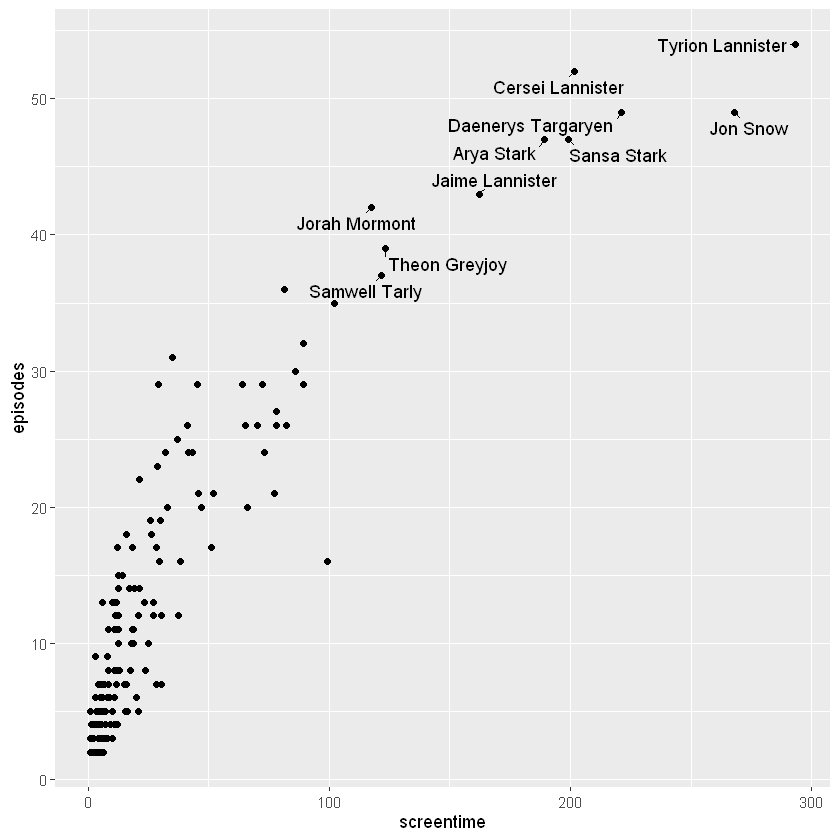

In [2]:
#| label: fig-plot
#| fig-cap: "Plot Screentime"

ggplot(screentimes, aes(screentime, episodes)) +
  geom_point() +
  geom_text_repel(data = screentimes_high,aes(label = name),min.segment.length = 0)

## Tabelle referenzieren

siehe [Quarto Dokumentation "Cross Referencing"](https://quarto.org/docs/authoring/cross-references.html) **"Tables" --> "Computations"**

Um eine computergenerierte Tabelle zu referenzieren (und eine Caption zu setzen) verwende ich die library `knitr`.

- im Code-Block zu Beginn einfügen:
    - `#| label: tbl-top10` --> Tag für die Tabelle
    - `#| tbl-cap: "Top 10 Characters by Screentime"` --> Name der Caption
- Dann Library laden --> `library(knitr)`
- Zuletzt Plot einfügen, der referenziert werden soll, mit `kable` davor --> `kable(Plot)`

Auf die Tabelle referenzieren kann ich dann wieder mit `@tbl-top10` --> siehe @tbl-top10

In [23]:
#| label: tbl-top10
#| tbl-cap: "Top 10 Characters by Screentime"

top_10 <- select(screentimes_high, c(name, screentime, episodes))

library(knitr)
kable(top_10)



|name               | screentime| episodes|
|:------------------|----------:|--------:|
|Tyrion Lannister   |     293.30|       54|
|Jon Snow           |     268.15|       49|
|Daenerys Targaryen |     221.30|       49|
|Cersei Lannister   |     201.45|       52|
|Sansa Stark        |     199.30|       47|
|Arya Stark         |     189.15|       47|
|Jaime Lannister    |     162.30|       43|
|Theon Greyjoy      |     123.30|       39|
|Samwell Tarly      |     121.45|       37|
|Jorah Mormont      |     117.30|       42|

## Paper zitieren {#sec-zitieren}

siehe [Quarto Dokumentation "Citations"](https://quarto.org/docs/authoring/citations.html)

Um ein Paper zu zitieren muss ich:

- das Paper suchen (z.B. Google Scholar) und die ***BibText-Datei*** mit den Zitierangaben herunterladen --> bei mir heisst die Datei `bibliography.bib`
- Datei in Jupyter laden
- YAML-Header anpassen: `bibliography: bibliography.bib`
- Im ***key*** (erste Zeile in der Datei, direkt nach `@article{KEY},`) der `.bib-Datei` definiere ich, wie ich die Zitierung einhole --> ich kann diese so setzen, wie ich will. Ich habe den key auf `@article{scherelis2025,` gesetzt, und kann die Zitierung somit mit `@scherelis2025` machen. siehe @scherelis2025

PS: zu unterst im File kommt die ganze Zitierung des Papers.